<a href="https://colab.research.google.com/github/navap3206-debug/hello-world/blob/main/A01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Para los datos de los archivos "bateria_tableta.txt" y "Salarios_minimos.csv":**

- Realiza regresiones polinomiales de orden 1, 3, 5 y 7.

- Compara el R2 que te da cada modelo.

- Crea una gráfica con una nube de dispersión (datos originales) y tus modelos.




In [140]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from google.colab import files
import matplotlib.pyplot as plt

# ***PREPARACIÓN DE LOS DATOS***

In [173]:
df = files.upload()

Saving Salarios_minimos.csv to Salarios_minimos (2).csv
Saving bateria_tableta.txt to bateria_tableta (2).txt


In [204]:
#Abrimos los archivos
salarios = pd.read_csv('Salarios_minimos.csv')
tableta = pd.read_csv('bateria_tableta.txt')

In [205]:
salarios.head(10) #identificamos el numero de variables en este caso Y y X donde la variable de control es el Periodo

,Periodo,Salario
0,1988.25,8.00
1,1989.00,8.64
2,1989.50,9.16
3,1990.00,10.08
4,1990.84,11.90
5,1991.84,13.33
6,1993.00,14.27
7,1994.00,15.27
8,1995.00,16.34
9,1995.30,18.30


In [206]:
tableta.head(10) #La variable de control es la carga

,carga,duracion
0,2.81,5.62
1,7.14,8.00
2,2.72,5.44
3,3.87,7.74
4,1.90,3.80
5,7.82,8.00
6,7.02,8.00
7,5.50,8.00
8,9.15,8.00
9,4.87,8.00


In [177]:
matriz_sl = salarios.to_numpy() #Transformamos en matriz manipulable con numpy
matriz_tb = tableta.to_numpy()

In [178]:
print(matriz_sl , matriz_tb, sep='\n \n') #Comprobamos su orden, en caso de carga debemos ordenar

[[1988.25    8.  ]
 [1989.      8.64]
 [1989.5     9.16]
 [1990.     10.08]
 [1990.84   11.9 ]
 [1991.84   13.33]
 [1993.     14.27]
 [1994.     15.27]
 [1995.     16.34]
 [1995.3    18.3 ]
 [1996.     20.15]
 [1996.3    22.6 ]
 [1997.     26.45]
 [1998.     30.2 ]
 [1999.     34.45]
 [2000.     37.9 ]
 [2001.     40.35]
 [2002.     42.15]
 [2003.     43.65]
 [2004.     45.24]
 [2005.     46.8 ]
 [2006.     48.67]
 [2007.     50.57]
 [2008.     52.59]
 [2009.     54.8 ]
 [2010.     57.46]
 [2011.     59.82]
 [2012.     62.33]
 [2013.     64.76]
 [2014.     67.29]
 [2015.     70.1 ]
 [2016.     73.04]
 [2017.     80.04]
 [2018.     88.36]]
 
[[ 2.81  5.62]
 [ 7.14  8.  ]
 [ 2.72  5.44]
 [ 3.87  7.74]
 [ 1.9   3.8 ]
 [ 7.82  8.  ]
 [ 7.02  8.  ]
 [ 5.5   8.  ]
 [ 9.15  8.  ]
 [ 4.87  8.  ]
 [ 8.08  8.  ]
 [ 5.58  8.  ]
 [ 9.13  8.  ]
 [ 0.14  0.28]
 [ 2.    4.  ]
 [ 5.47  8.  ]
 [ 0.8   1.6 ]
 [ 4.37  8.  ]
 [ 5.31  8.  ]
 [ 0.    0.  ]
 [ 1.78  3.56]
 [ 3.45  6.9 ]
 [ 6.13  8.  ]
 [ 3.5

**REGRESIÓN PARA SALARIOS MINIMOS Y DURACIÓN DE CARGA**

Elección de datos de prueba...




In [253]:
print("1) Salarios")
print("2) Duración de carga")
ans = int(input("Datos de ajuste..."))


if ans == 1:
  matriz_ = matriz_sl
  print("Datos de salarios")

elif ans == 2:
  matriz_ = matriz_tb
  print("Datos de carga")
else:
  print("Error")

1) Salarios
2) Duración de carga
Datos de ajuste...2
Datos de carga


COmo se menciono, será necesario reordenar el vector Y...

In [260]:
# matriz[:, 0] selecciona todos los elementos de la primera columna
indices = np.argsort(matriz_[:, 0])

# 2. Aplicamos esos índices a toda la matriz para reordenar las filas
matriz_ = matriz_[indices]
#comprobamos
matriz_


array([[ 0.  ,  0.  ],
       [ 0.02,  0.04],
       [ 0.13,  0.26],
       [ 0.14,  0.28],
       [ 0.39,  0.78],
       [ 0.8 ,  1.6 ],
       [ 1.1 ,  2.2 ],
       [ 1.11,  2.22],
       [ 1.14,  2.28],
       [ 1.26,  2.52],
       [ 1.27,  2.54],
       [ 1.44,  2.88],
       [ 1.58,  3.16],
       [ 1.58,  3.16],
       [ 1.66,  3.32],
       [ 1.75,  3.5 ],
       [ 1.76,  3.52],
       [ 1.78,  3.56],
       [ 1.83,  3.66],
       [ 1.83,  3.66],
       [ 1.85,  3.7 ],
       [ 1.89,  3.78],
       [ 1.9 ,  3.8 ],
       [ 1.98,  3.96],
       [ 1.98,  3.96],
       [ 1.99,  3.98],
       [ 2.  ,  4.  ],
       [ 2.04,  4.08],
       [ 2.06,  4.12],
       [ 2.15,  4.3 ],
       [ 2.16,  4.32],
       [ 2.24,  4.48],
       [ 2.33,  4.66],
       [ 2.58,  5.16],
       [ 2.72,  5.44],
       [ 2.81,  5.62],
       [ 3.42,  6.84],
       [ 3.45,  6.9 ],
       [ 3.47,  6.94],
       [ 3.53,  7.06],
       [ 3.65,  7.3 ],
       [ 3.77,  7.54],
       [ 3.87,  7.74],
       [ 3.

In [261]:
#DIVIDIMOS LAS MATRICES EN X Y Y
xsl_matrix = np.array([[sl[0]] for sl in matriz_])
y_vec = np.array([[sl[1]] for sl in matriz_])
print(xsl_matrix)
print(y_vec)


[[ 0.  ]
 [ 0.02]
 [ 0.13]
 [ 0.14]
 [ 0.39]
 [ 0.8 ]
 [ 1.1 ]
 [ 1.11]
 [ 1.14]
 [ 1.26]
 [ 1.27]
 [ 1.44]
 [ 1.58]
 [ 1.58]
 [ 1.66]
 [ 1.75]
 [ 1.76]
 [ 1.78]
 [ 1.83]
 [ 1.83]
 [ 1.85]
 [ 1.89]
 [ 1.9 ]
 [ 1.98]
 [ 1.98]
 [ 1.99]
 [ 2.  ]
 [ 2.04]
 [ 2.06]
 [ 2.15]
 [ 2.16]
 [ 2.24]
 [ 2.33]
 [ 2.58]
 [ 2.72]
 [ 2.81]
 [ 3.42]
 [ 3.45]
 [ 3.47]
 [ 3.53]
 [ 3.65]
 [ 3.77]
 [ 3.87]
 [ 3.97]
 [ 3.97]
 [ 3.99]
 [ 4.11]
 [ 4.15]
 [ 4.35]
 [ 4.37]
 [ 4.38]
 [ 4.39]
 [ 4.61]
 [ 4.64]
 [ 4.71]
 [ 4.87]
 [ 4.93]
 [ 5.26]
 [ 5.31]
 [ 5.33]
 [ 5.39]
 [ 5.47]
 [ 5.5 ]
 [ 5.55]
 [ 5.58]
 [ 5.68]
 [ 5.75]
 [ 5.77]
 [ 5.94]
 [ 5.96]
 [ 6.05]
 [ 6.13]
 [ 6.37]
 [ 6.39]
 [ 6.48]
 [ 6.65]
 [ 6.71]
 [ 7.02]
 [ 7.14]
 [ 7.37]
 [ 7.53]
 [ 7.79]
 [ 7.8 ]
 [ 7.82]
 [ 8.05]
 [ 8.06]
 [ 8.08]
 [ 8.21]
 [ 8.38]
 [ 8.43]
 [ 8.49]
 [ 8.79]
 [ 9.13]
 [ 9.15]
 [ 9.2 ]
 [ 9.29]
 [ 9.33]
 [ 9.69]
 [ 9.71]
 [11.72]]
[[0.  ]
 [0.04]
 [0.26]
 [0.28]
 [0.78]
 [1.6 ]
 [2.2 ]
 [2.22]
 [2.28]
 [2.52]
 [2.54]
 [2.88]
 [3

*GRADO 1*

Procedimiento general:


*   Ajustamos la regresión
*   Identificamos el intercepto
*   Buscamos el error mediante R2
*   Identificamos los coeficientes de las variables libres
*   COnformamos la ecuación de la recta e imprimimos en la grafica



In [262]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos
lr.fit(xsl_matrix, y_vec) #Entrenamos la regresión
inter = lr.intercept_  #Intercepto
inter

array([2.87054111])

In [263]:
lr.score(xsl_matrix, y_vec)

0.6872269726243968

In [264]:
var = lr.coef_ #variables libres ajustadas
var

array([[0.72955585]])

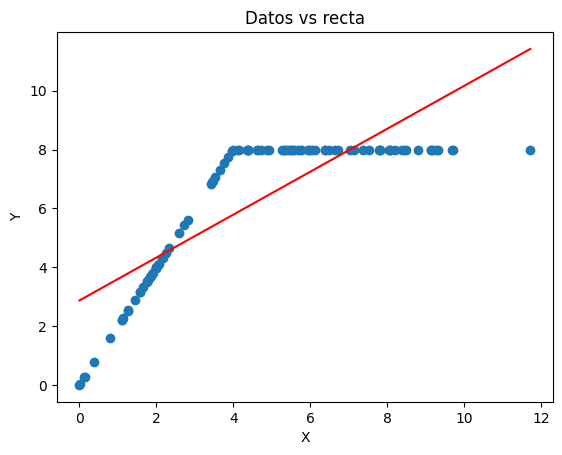

In [265]:
x = xsl_matrix
y = y_vec

y_recta = inter + var * x

plt.scatter(x, y)
plt.plot(x, y_recta, color='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()

*GRADO 3*

In [266]:
#Creo arrays de X / Y, además de agregar variable libre de grado 2
x3sl_matrix = np.array([[sl[0], sl[0]**3, sl[0]**3] for sl in matriz_])
y_vec = np.array([[sl[1]] for sl in matriz_])
x3sl_matrix

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.00000000e-02, 8.00000000e-06, 8.00000000e-06],
       [1.30000000e-01, 2.19700000e-03, 2.19700000e-03],
       [1.40000000e-01, 2.74400000e-03, 2.74400000e-03],
       [3.90000000e-01, 5.93190000e-02, 5.93190000e-02],
       [8.00000000e-01, 5.12000000e-01, 5.12000000e-01],
       [1.10000000e+00, 1.33100000e+00, 1.33100000e+00],
       [1.11000000e+00, 1.36763100e+00, 1.36763100e+00],
       [1.14000000e+00, 1.48154400e+00, 1.48154400e+00],
       [1.26000000e+00, 2.00037600e+00, 2.00037600e+00],
       [1.27000000e+00, 2.04838300e+00, 2.04838300e+00],
       [1.44000000e+00, 2.98598400e+00, 2.98598400e+00],
       [1.58000000e+00, 3.94431200e+00, 3.94431200e+00],
       [1.58000000e+00, 3.94431200e+00, 3.94431200e+00],
       [1.66000000e+00, 4.57429600e+00, 4.57429600e+00],
       [1.75000000e+00, 5.35937500e+00, 5.35937500e+00],
       [1.76000000e+00, 5.45177600e+00, 5.45177600e+00],
       [1.78000000e+00, 5.63975

In [283]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos en nuestra matriz
lr.fit(x3sl_matrix, y_vec) #Entrenamos la regresión
inter_3 = lr.intercept_  #Intercepto
inter_3

array([0.97906678])

In [284]:
lr.score(x3sl_matrix, y_vec) #R2

0.914067691707562

In [285]:
var_3 = lr.coef_ #variables libres ajustadas
var_3

array([[ 1.55757279, -0.00455973, -0.00455973]])

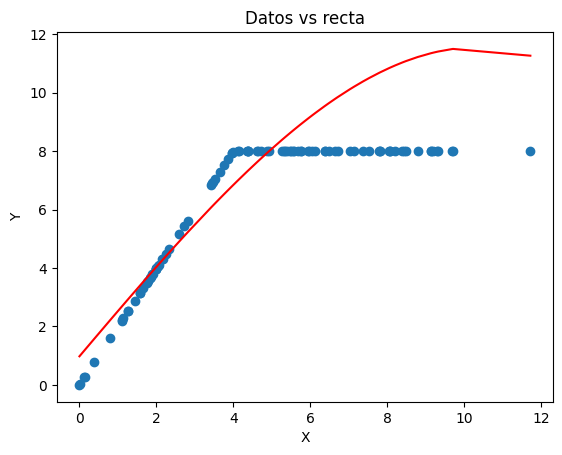

In [286]:
x = xsl_matrix
y = y_vec

y_recta_3 = inter_3 + var_3[0,0] * x**1 + var_3[0,1] * x**2 + var_3[0,2] * x**3

plt.scatter(x, y)
plt.plot(x, y_recta_3, color='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()

*GRADO 5*

In [271]:
#Creo arrays de X / Y, además de agregar variable libre de grado 5
x5sl_matrix = np.array([[sl[0], sl[0]**2,sl[0]**3,sl[0]**4,sl[0]**5] for sl in matriz_])
y_vec = np.array([[sl[1]] for sl in matriz_])
x5sl_matrix

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00],
       [2.00000000e-02, 4.00000000e-04, 8.00000000e-06, 1.60000000e-07,
        3.20000000e-09],
       [1.30000000e-01, 1.69000000e-02, 2.19700000e-03, 2.85610000e-04,
        3.71293000e-05],
       [1.40000000e-01, 1.96000000e-02, 2.74400000e-03, 3.84160000e-04,
        5.37824000e-05],
       [3.90000000e-01, 1.52100000e-01, 5.93190000e-02, 2.31344100e-02,
        9.02241990e-03],
       [8.00000000e-01, 6.40000000e-01, 5.12000000e-01, 4.09600000e-01,
        3.27680000e-01],
       [1.10000000e+00, 1.21000000e+00, 1.33100000e+00, 1.46410000e+00,
        1.61051000e+00],
       [1.11000000e+00, 1.23210000e+00, 1.36763100e+00, 1.51807041e+00,
        1.68505816e+00],
       [1.14000000e+00, 1.29960000e+00, 1.48154400e+00, 1.68896016e+00,
        1.92541458e+00],
       [1.26000000e+00, 1.58760000e+00, 2.00037600e+00, 2.52047376e+00,
        3.17579694e+00],
       [1.27000000e+00, 1.6129

In [272]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos
lr.fit(x5sl_matrix, y_vec) #Entrenamos la regresión
inter_5 = lr.intercept_  #Intercepto
inter_5

array([0.14276245])

In [273]:
lr.score(x5sl_matrix, y_vec)

0.9953630126134433

In [274]:
var_5 = lr.coef_ #variables libres ajustadas
var_5

array([[ 8.35890085e-01,  1.10347381e+00, -3.23550360e-01,
         3.20123836e-02, -1.07054199e-03]])

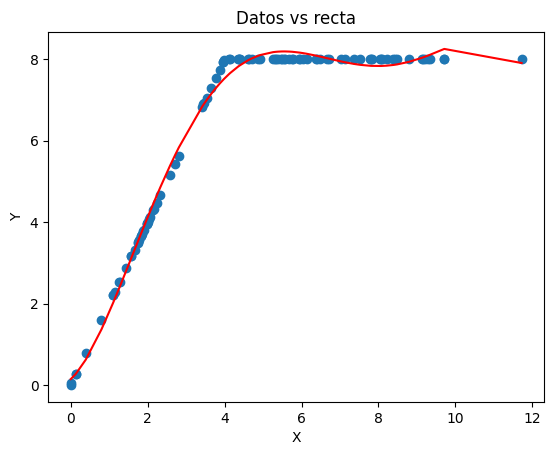

In [275]:
x = xsl_matrix
y = y_vec

y_recta_5 = inter_5 + var_5[0,0] * x**1 + var_5[0,1] * x**2 + var_5[0,2] * x**3 + var_5[0,3] * x**4 + var_5[0,4] * x**5

plt.scatter(x, y)
plt.plot(x, y_recta_5, color='red')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()

*GRADO 7*

In [276]:
x7sl_matrix = np.array([[sl[0], sl[0]**2,sl[0]**3,sl[0]**4,sl[0]**5,sl[0]**6,sl[0]**7] for sl in matriz_])
y7Sl_matrix = np.array([[sl[1]] for sl in matriz_])
x7sl_matrix

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 0.00000000e+00],
       [2.00000000e-02, 4.00000000e-04, 8.00000000e-06, 1.60000000e-07,
        3.20000000e-09, 6.40000000e-11, 1.28000000e-12],
       [1.30000000e-01, 1.69000000e-02, 2.19700000e-03, 2.85610000e-04,
        3.71293000e-05, 4.82680900e-06, 6.27485170e-07],
       [1.40000000e-01, 1.96000000e-02, 2.74400000e-03, 3.84160000e-04,
        5.37824000e-05, 7.52953600e-06, 1.05413504e-06],
       [3.90000000e-01, 1.52100000e-01, 5.93190000e-02, 2.31344100e-02,
        9.02241990e-03, 3.51874376e-03, 1.37231007e-03],
       [8.00000000e-01, 6.40000000e-01, 5.12000000e-01, 4.09600000e-01,
        3.27680000e-01, 2.62144000e-01, 2.09715200e-01],
       [1.10000000e+00, 1.21000000e+00, 1.33100000e+00, 1.46410000e+00,
        1.61051000e+00, 1.77156100e+00, 1.94871710e+00],
       [1.11000000e+00, 1.23210000e+00, 1.36763100e+00, 1.51807041e+00,
        1.68505816e+00, 1

In [277]:
lr = LinearRegression(fit_intercept= True) #no consideramos los interceptos
lr.fit(x7sl_matrix, y_vec) #Entrenamos la regresión
inter_7 = lr.intercept_  #Intercepto
inter_7

array([-0.02673001])

In [278]:
lr.score(x7sl_matrix, y_vec)

0.9980965602454174

In [279]:
var_7 = lr.coef_
var_7

array([[ 2.63586646e+00, -1.38252388e+00,  1.01240187e+00,
        -3.16715233e-01,  4.60134802e-02, -3.15491538e-03,
         8.27801489e-05]])

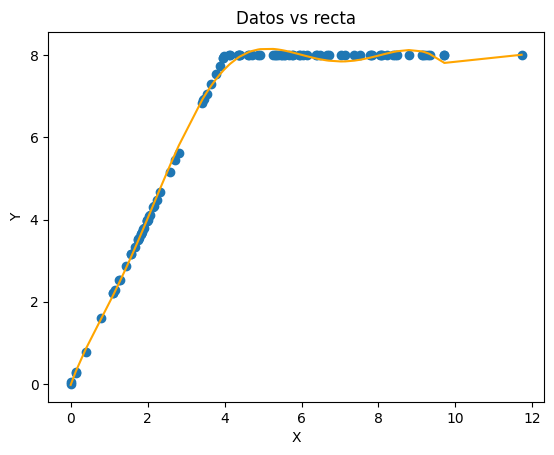

In [280]:
x = xsl_matrix
y = y_vec

y_recta_7 = inter_7 + var_7[0,0] * x**1 + var_7[0,1] * x**2 + var_7[0,2] * x**3 + var_7[0,3] * x**4 + var_7[0,4] * x**5 + var_7[0,5] * x**6 + var_7[0,6] * x**7

plt.scatter(x, y)
plt.plot(x, y_recta_7, color='orange')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()


***COMPARAMOS LAS REGRESIONES ... ***

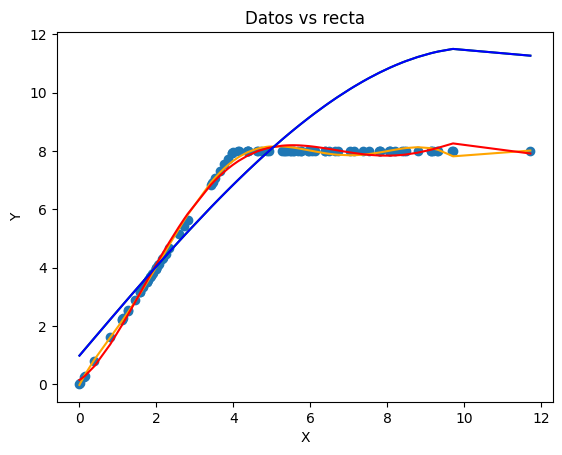

In [287]:
x = xsl_matrix
y = y_vec


plt.scatter(x, y)
plt.plot(x, y_recta_7, color='orange')
plt.plot(x, y_recta_5, color='red')
plt.plot(x, y_recta_3, color='green')
plt.plot(x, y_recta, color='blue')


plt.xlabel("X")
plt.ylabel("Y")
plt.title("Datos vs recta")

plt.show()
